In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# CELL 1 - CONFIG
import os
import re
import hashlib
import random
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_DIR = "/content/drive/MyDrive/NLP/Final/Data/QA"
OUTPUT_DIR = "/content/drive/MyDrive/NLP/Final/Data/QA/spcqa_v4_best_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_TOTAL = 32000
SEED = 20260513

# Vì đây là file train_qa, mặc định set toàn bộ output thành train để tránh lẫn split.
# Nếu muốn giữ split theo ảnh, đổi thành "image_level_preserve".
SPLIT_MODE = "image_level_preserve"  # options: "all_train", "image_level_preserve"

FILE_NAMES = {
    "ca_chua": "ca_chua_train_qa_standard_core_with_real_image_path.csv",
    "bi_do": "bi_do_train_qa_standard_core_with_real_image_path.csv",
    "kho_qua": "kho_qua_train_qa_standard_core_with_real_image_path.csv",
    "dua_leo": "dua_leo_train_qa_standard_core_with_real_image_path.csv",
}

AUGMENT_CROPS = ["bi_do", "kho_qua", "dua_leo"]
REFERENCE_CROP = "ca_chua"

PREFIX = {
    "ca_chua": "CACHUA",
    "bi_do": "BIDO",
    "kho_qua": "KHOQUA",
    "dua_leo": "DUALEO",
}

# Mục tiêu phân bố question_type sau tăng cường.
# Nếu dữ liệu gốc có question_type nào vượt target thì code vẫn giữ dữ liệu gốc và phân bổ phần augment còn lại.
DESIRED_QTYPE_FINAL = {
    "identification": 2560,
    "visual_evidence": 3840,
    "differential_diagnosis": 3840,
    "initial_action": 5440,
    "severity_assessment": 3520,
    "followup_needed": 3200,
    "safety_check": 2560,
    "uncertainty": 2560,
    "weather_risk": 1920,
    "general_consultation": 2560,
}
assert sum(DESIRED_QTYPE_FINAL.values()) == TARGET_TOTAL

print("INPUT_DIR:", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("SPLIT_MODE:", SPLIT_MODE)

INPUT_DIR: /content/drive/MyDrive/NLP/Final/Data/QA
OUTPUT_DIR: /content/drive/MyDrive/NLP/Final/Data/QA/spcqa_v4_best_output
SPLIT_MODE: image_level_preserve


In [14]:
# CELL 2 - LOAD + BASIC CHECK
def load_datasets(input_dir=INPUT_DIR, file_names=FILE_NAMES):
    dfs = {}
    for crop_key, file_name in file_names.items():
        path = os.path.join(input_dir, file_name)
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"Không tìm thấy file: {path}\n"
                "Nếu file nằm trong Drive, hãy sửa INPUT_DIR ở phần config."
            )
        dfs[crop_key] = pd.read_csv(path)
        print(f"{crop_key}: {dfs[crop_key].shape}")
    return dfs


def check_initial_schema(dfs):
    base_cols = list(dfs[REFERENCE_CROP].columns)
    content_cols = [c for c in base_cols if c != "sample_id"]
    rows = []
    for crop_key, df in dfs.items():
        rows.append({
            "crop": crop_key,
            "rows": len(df),
            "columns": len(df.columns),
            "schema_ok": list(df.columns) == base_cols,
            "duplicate_columns": int(df.columns.duplicated().sum()),
            "duplicate_content_excluding_sample_id": int(df.duplicated(subset=content_cols).sum()),
            "unique_images": int(df["image_id"].nunique()) if "image_id" in df.columns else None,
            "num_labels": int(df["canonical_label"].nunique()) if "canonical_label" in df.columns else None,
            "num_question_types": int(df["question_type"].nunique()) if "question_type" in df.columns else None,
            "null_cells": int(df.isna().sum().sum()),
        })
    summary = pd.DataFrame(rows)
    display(summary)
    assert summary["schema_ok"].all(), "Có file bị lệch schema."
    assert summary["duplicate_columns"].sum() == 0, "Có duplicate cột."
    return base_cols, content_cols, summary

dfs = load_datasets()
BASE_COLS, CONTENT_COLS, initial_summary = check_initial_schema(dfs)

ca_chua: (32000, 22)
bi_do: (12000, 22)
kho_qua: (15480, 22)
dua_leo: (10080, 22)


,crop,rows,columns,schema_ok,duplicate_columns,duplicate_content_excluding_sample_id,unique_images,num_labels,num_question_types,null_cells
0,ca_chua,32000,22,True,0,0,4000,10,9,0
1,bi_do,12000,22,True,0,1600,2000,5,9,0
2,kho_qua,15480,22,True,0,0,2580,9,8,0
3,dua_leo,10080,22,True,0,0,1680,5,8,0


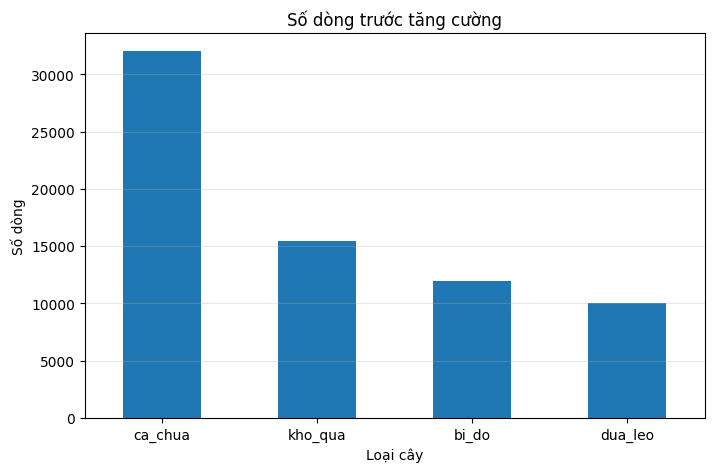

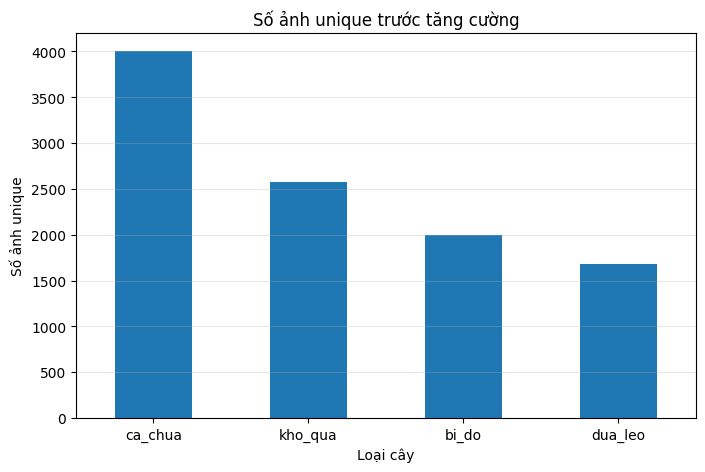

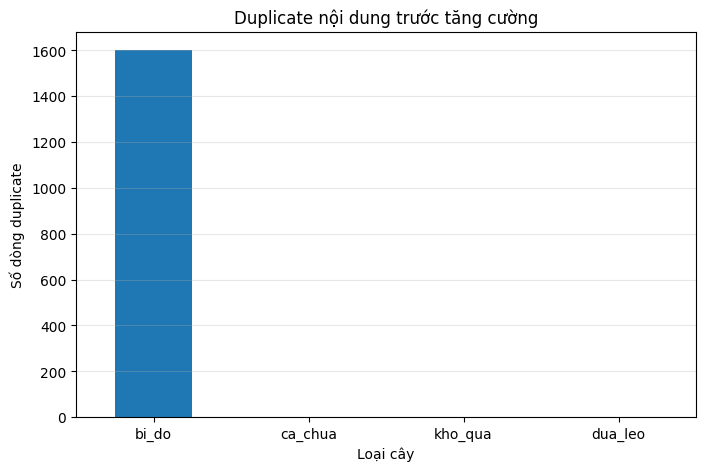

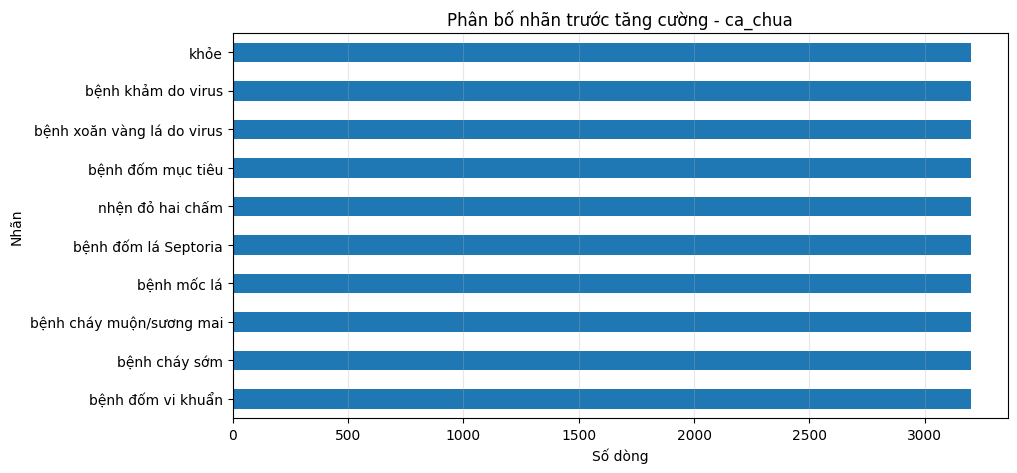

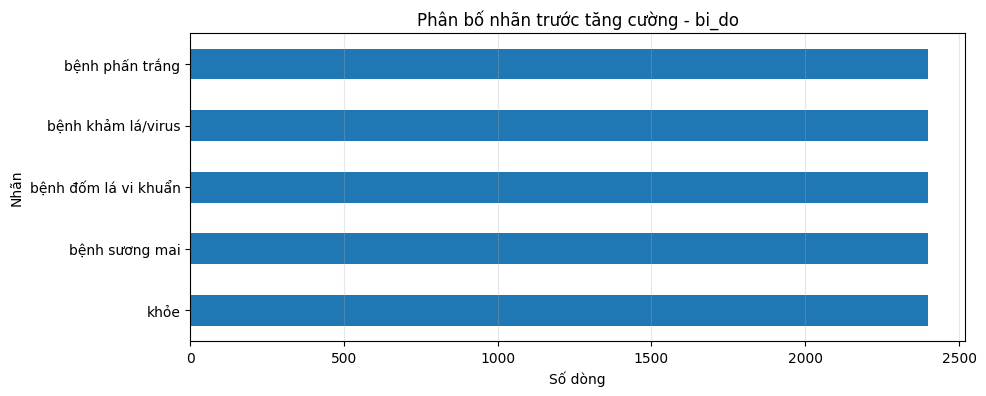

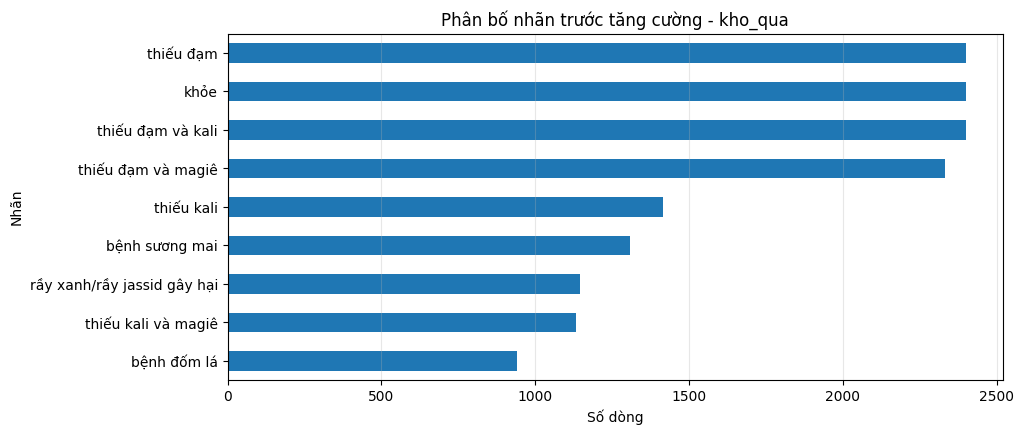

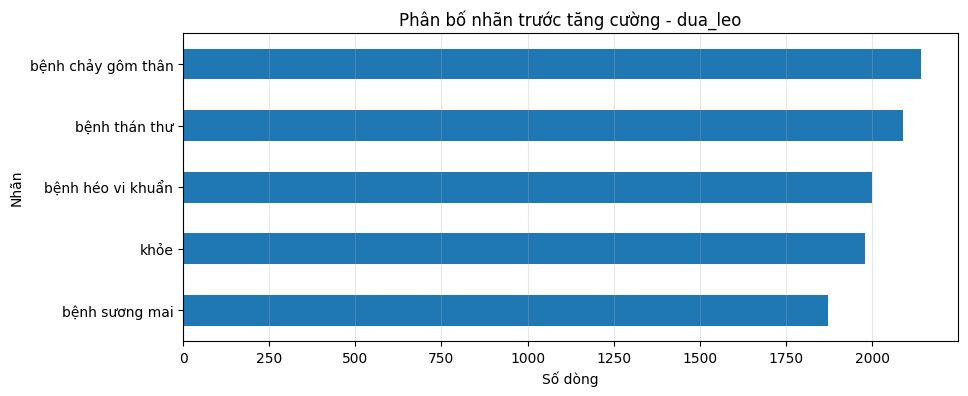

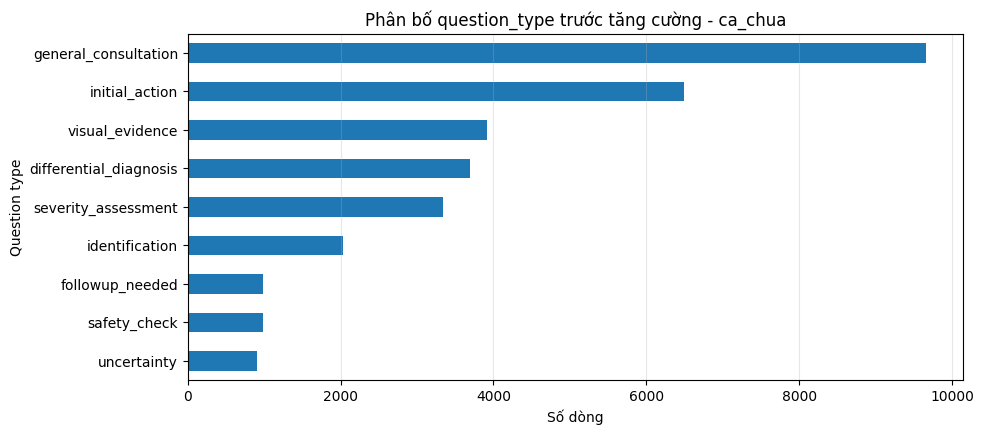

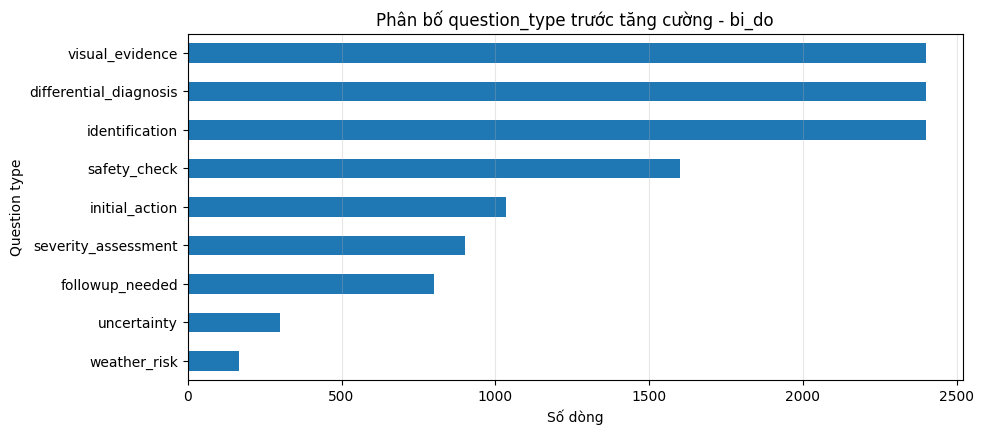

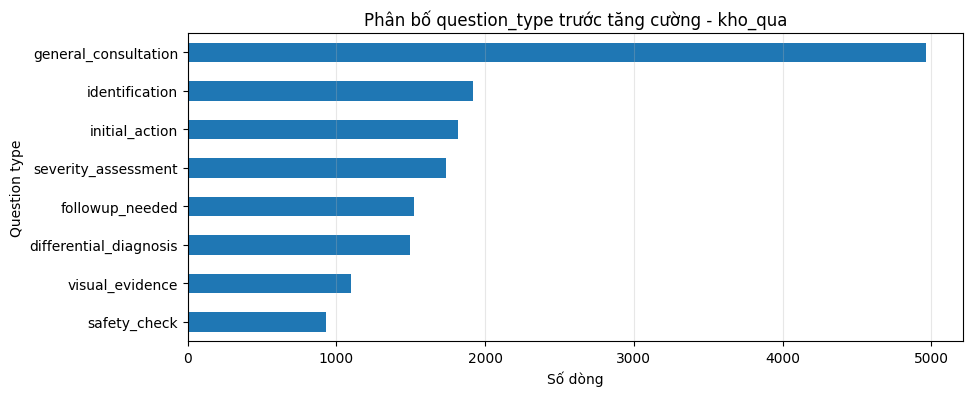

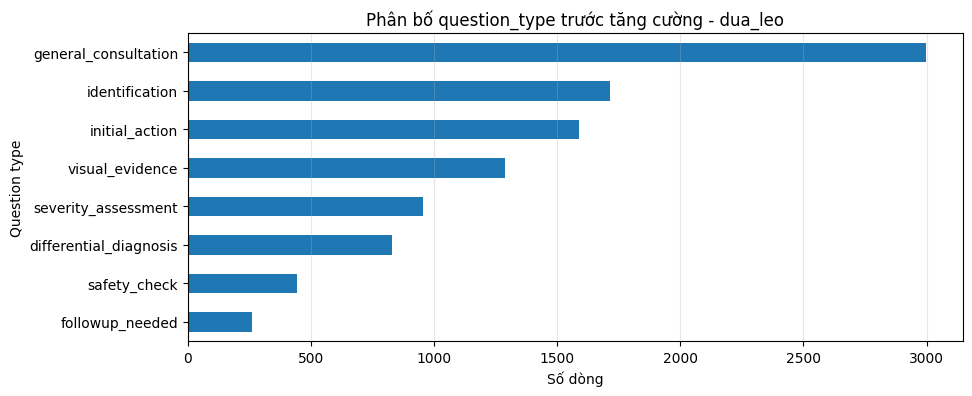

In [15]:
# CELL 3 - VISUALIZE BEFORE AUGMENTATION
def plot_before_augmentation(dfs, content_cols):
    row_counts = pd.Series({k: len(v) for k, v in dfs.items()}).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    row_counts.plot(kind="bar")
    plt.title("Số dòng trước tăng cường")
    plt.xlabel("Loại cây")
    plt.ylabel("Số dòng")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    image_counts = pd.Series({k: v["image_id"].nunique() for k, v in dfs.items()}).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    image_counts.plot(kind="bar")
    plt.title("Số ảnh unique trước tăng cường")
    plt.xlabel("Loại cây")
    plt.ylabel("Số ảnh unique")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    duplicate_counts = pd.Series({k: v.duplicated(subset=content_cols).sum() for k, v in dfs.items()}).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    duplicate_counts.plot(kind="bar")
    plt.title("Duplicate nội dung trước tăng cường")
    plt.xlabel("Loại cây")
    plt.ylabel("Số dòng duplicate")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    for crop_key, df in dfs.items():
        counts = df["canonical_label"].value_counts().sort_values(ascending=True)
        plt.figure(figsize=(10, max(4, len(counts) * 0.5)))
        counts.plot(kind="barh")
        plt.title(f"Phân bố nhãn trước tăng cường - {crop_key}")
        plt.xlabel("Số dòng")
        plt.ylabel("Nhãn")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

    for crop_key, df in dfs.items():
        counts = df["question_type"].value_counts().sort_values(ascending=True)
        plt.figure(figsize=(10, max(4, len(counts) * 0.5)))
        counts.plot(kind="barh")
        plt.title(f"Phân bố question_type trước tăng cường - {crop_key}")
        plt.xlabel("Số dòng")
        plt.ylabel("Question type")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

plot_before_augmentation(dfs, CONTENT_COLS)

In [16]:
# CELL 4 - TEXT PROCESSING + RULES
def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def normalize_text(x):
    s = safe_text(x).lower()
    s = re.sub(r"[/_\-]+", " ", s)
    s = re.sub(r"[^\w\sÀ-ỹ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def recompute_label_mentioned(label, question):
    label_norm = normalize_text(label)
    q_norm = normalize_text(question)
    if not label_norm:
        return "no"
    return "yes" if label_norm in q_norm else "no"


def label_readable(label):
    label = safe_text(label)
    if label == "khỏe":
        return "tình trạng khỏe hoặc chưa thấy dấu bệnh đặc trưng"
    return label


def pick_confuser(label, labels, crop, image_id="", variant=0):
    label_norm = normalize_text(label)
    labels = list(labels)

    if label_norm == "khỏe":
        return "lá già, thay đổi ánh sáng, stress nước hoặc thiếu dinh dưỡng nhẹ"

    candidates = [x for x in labels if x != label]
    if not candidates:
        return "nguyên nhân khác có triệu chứng gần giống"

    disease_groups = {
        "sương mai": ["bệnh đốm lá", "bệnh phấn trắng", "bệnh cháy muộn/sương mai", "bệnh thán thư"],
        "đốm": ["bệnh sương mai", "bệnh thán thư", "bệnh đốm lá vi khuẩn", "thiếu kali"],
        "thán thư": ["bệnh sương mai", "bệnh đốm lá", "bệnh chảy gôm thân"],
        "héo": ["stress nước", "thối rễ", "bệnh chảy gôm thân"],
        "phấn trắng": ["bệnh sương mai", "bụi bẩn trên lá", "vết bạc do côn trùng"],
        "khảm": ["thiếu dinh dưỡng", "rầy xanh/rầy jassid gây hại", "stress môi trường"],
        "thiếu đạm": ["thiếu kali", "thiếu magiê", "lá già tự nhiên"],
        "thiếu kali": ["thiếu đạm", "thiếu magiê", "bệnh đốm lá"],
        "rầy": ["thiếu dinh dưỡng", "virus", "stress khô hạn"],
    }

    prioritized = []
    for k, vals in disease_groups.items():
        if k in label_norm:
            prioritized += [v for v in vals if v in candidates]

    if prioritized:
        candidates = prioritized

    key = int(hashlib.md5(f"{crop}-{image_id}-{label}-{variant}".encode("utf-8")).hexdigest(), 16)
    return candidates[key % len(candidates)]


def action_text(label):
    n = normalize_text(label)

    if n == "khỏe":
        return (
            "tiếp tục theo dõi, giữ vườn thông thoáng, tưới và bón cân đối, "
            "đồng thời chụp lại nếu xuất hiện vết mới hoặc cây suy nhanh"
        )
    if "thiếu" in n:
        return (
            "kiểm tra lịch bón phân, pH và ẩm độ đất; điều chỉnh dinh dưỡng từ từ, "
            "tránh bón dồn liều cao trong một lần"
        )
    if "khảm" in n or "virus" in n or "xoăn" in n:
        return (
            "cách ly cây nghi ngờ, vệ sinh dụng cụ, kiểm tra côn trùng môi giới "
            "và không dùng cây có triệu chứng để nhân giống"
        )
    if "rầy" in n or "jassid" in n or "nhện" in n or "sâu" in n:
        return (
            "kiểm tra mặt dưới lá và mật số sâu hại, dọn cỏ/ký chủ phụ, "
            "theo dõi lá non và loại bỏ phần bị hại nặng nếu cần"
        )
    if "héo" in n or "vi khuẩn" in n:
        return (
            "giữ vườn sạch, tưới gốc, hạn chế làm việc khi cây ướt, "
            "vệ sinh dụng cụ và theo dõi tốc độ héo trên cây"
        )
    if "phấn trắng" in n:
        return (
            "giữ tán thông thoáng, giảm ẩm trên lá, tránh tưới phun lên tán "
            "và loại bỏ lá bệnh nặng"
        )
    if any(k in n for k in ["sương mai", "thán thư", "đốm", "nấm", "mốc", "cháy"]):
        return (
            "giữ lá khô, tưới gốc, tăng thông thoáng, dọn lá bệnh nặng "
            "và theo dõi vết mới sau mưa hoặc khi ẩm độ cao"
        )
    return (
        "theo dõi thêm, cải thiện chăm sóc cơ bản, giữ vườn thông thoáng "
        "và kiểm tra triệu chứng trên nhiều lá hoặc nhiều cây"
    )


def confidence_sentence(confidence):
    n = normalize_text(confidence)
    if "thấp" in n:
        return "Vì độ chắc chắn thấp, cần giữ kết luận ở mức nghi ngờ và bổ sung thêm ảnh hoặc thông tin vườn."
    if "cao" in n:
        return "Độ chắc chắn tương đối cao, nhưng vẫn nên đối chiếu thêm trên nhiều lá hoặc nhiều cây."
    return "Độ chắc chắn ở mức trung bình, nên kết luận thận trọng và tiếp tục theo dõi diễn biến."


def build_input(row, question, with_label):
    base = (
        f"Cây trồng: {safe_text(row['crop'])}. "
        f"Triệu chứng quan sát: {safe_text(row['visible_symptoms'])}. "
        f"Vị trí triệu chứng: {safe_text(row['lesion_location'])}. "
        f"Mẫu triệu chứng: {safe_text(row['symptom_pattern'])}. "
        f"Mức độ: {safe_text(row['severity_level'])}. "
        f"Chất lượng ảnh: {safe_text(row['image_quality'])}. "
        f"Độ chắc chắn: {safe_text(row['confidence_level'])}. "
    )
    if with_label:
        base = (
            f"Cây trồng: {safe_text(row['crop'])}. "
            f"Nhãn tham chiếu: {safe_text(row['canonical_label'])}. "
            f"Triệu chứng quan sát: {safe_text(row['visible_symptoms'])}. "
            f"Vị trí triệu chứng: {safe_text(row['lesion_location'])}. "
            f"Mẫu triệu chứng: {safe_text(row['symptom_pattern'])}. "
            f"Mức độ: {safe_text(row['severity_level'])}. "
            f"Chất lượng ảnh: {safe_text(row['image_quality'])}. "
            f"Độ chắc chắn: {safe_text(row['confidence_level'])}. "
        )
    return base + f"Câu hỏi: {question}"


def make_short_symptom(row, max_len=105):
    s = safe_text(row.get("visible_symptoms", ""))
    parts = re.split(r"[.;]\s+", s)
    s = parts[0].strip() if parts and parts[0].strip() else s.strip()
    s = re.sub(r"\s+", " ", s)
    if len(s) > max_len:
        s = s[:max_len].rsplit(" ", 1)[0] + "..."
    return s


def lower_first(sentence):
    sentence = safe_text(sentence)
    if not sentence:
        return sentence
    return sentence[0].lower() + sentence[1:]

In [17]:
# CELL 5 - QUESTION TEMPLATES
# =========================
QTEMPLATES = {
    "identification": [
        lambda r,c: f"Dựa trên triệu chứng ở {safe_text(r['lesion_location'])}, tình trạng của {safe_text(r['crop'])} nên được nhận định theo hướng nào?",
        lambda r,c: f"Ảnh này gợi ý vấn đề gì trên cây {safe_text(r['crop'])}?",
        lambda r,c: f"Nếu mô tả khách quan dấu hiệu {safe_text(r['symptom_pattern'])}, hướng chẩn đoán nào cần ưu tiên?",
        lambda r,c: f"Với biểu hiện hiện tại, có thể xếp mẫu này vào nhóm tình trạng nào?",
        lambda r,c: f"Nhìn vào vùng {safe_text(r['lesion_location'])}, nhận định sơ bộ nên nghiêng về đâu?",
        lambda r,c: f"Từ ảnh này, người trồng nên hiểu cây đang khỏe hay có vấn đề cần theo dõi?",
        lambda r,c: f"Dựa vào dấu hiệu {safe_text(r['symptom_pattern'])}, nhãn tham chiếu phù hợp nhất là gì?",
        lambda r,c: f"Khi chỉ có một ảnh cận cảnh, nên diễn đạt kết luận nhận dạng như thế nào?",
        lambda r,c: f"Ảnh này có đủ dấu hiệu để liên hệ với {safe_text(r['canonical_label'])} không?",
        lambda r,c: f"Nếu cần chọn một hướng kiểm tra chính cho cây này, nên chọn hướng nào?",
        lambda r,c: f"Triệu chứng được ghi nhận đang phù hợp với nhóm vấn đề nào trên cây?",
        lambda r,c: f"Quan sát nhanh ảnh này nên đưa ra nhận định ban đầu ra sao?",
    ],
    "visual_evidence": [
        lambda r,c: f"Dấu hiệu thị giác nào trong ảnh là căn cứ quan trọng nhất?",
        lambda r,c: f"Chi tiết nào ở {safe_text(r['lesion_location'])} cần được ưu tiên quan sát?",
        lambda r,c: f"Mẫu {safe_text(r['symptom_pattern'])} có ý nghĩa gì khi đánh giá ảnh này?",
        lambda r,c: f"Bằng chứng nào giúp liên hệ ảnh này với tình trạng đang nghi ngờ?",
        lambda r,c: f"Nếu giải thích cho người trồng, nên chỉ ra dấu hiệu nào trước?",
        lambda r,c: f"Điểm khác thường rõ nhất trong ảnh nằm ở đâu và thể hiện ra sao?",
        lambda r,c: f"Triệu chứng nào nên được dùng làm bằng chứng chính thay vì chỉ nhìn màu tổng thể?",
        lambda r,c: f"Cần mô tả phần lá/thân trong ảnh như thế nào để tránh suy luận quá mức?",
        lambda r,c: f"Dấu hiệu {safe_text(r['symptom_pattern'])} có phải bằng chứng đủ mạnh không?",
        lambda r,c: f"Khi ảnh có chất lượng {safe_text(r['image_quality'])}, bằng chứng nào còn đáng tin nhất?",
        lambda r,c: f"Vùng tổn thương trong ảnh cho thấy đặc điểm gì đáng chú ý?",
        lambda r,c: f"Nếu bỏ qua tên bệnh, ảnh này nên được mô tả bằng các dấu hiệu nào?",
    ],
    "differential_diagnosis": [
        lambda r,c: f"Biểu hiện này dễ nhầm với {c} ở điểm nào?",
        lambda r,c: f"Cần phân biệt tình trạng này với nguyên nhân nào trước khi xử lý?",
        lambda r,c: f"Vì sao không nên kết luận ngay chỉ từ một dấu hiệu trên ảnh?",
        lambda r,c: f"Dấu hiệu nào chưa đủ mạnh để loại trừ {c}?",
        lambda r,c: f"Nếu có hai khả năng gần giống nhau, nên so sánh những chi tiết nào?",
        lambda r,c: f"Điểm nào giúp phân biệt {safe_text(r['canonical_label'])} với {c}?",
        lambda r,c: f"Trong điều kiện ảnh hiện tại, rủi ro chẩn đoán nhầm nằm ở đâu?",
        lambda r,c: f"Triệu chứng {safe_text(r['symptom_pattern'])} có thể bị hiểu nhầm theo hướng nào?",
        lambda r,c: f"Cần kiểm tra thêm gì để không nhầm biểu hiện này với {c}?",
        lambda r,c: f"Nếu người trồng đã nghi {c}, nên giải thích lại thế nào?",
        lambda r,c: f"Có dấu hiệu nào ủng hộ nhãn hiện tại hơn so với nguyên nhân dễ nhầm không?",
        lambda r,c: f"Những nguyên nhân nào nên được đặt vào danh sách loại trừ?",
    ],
    "initial_action": [
        lambda r,c: f"Bước xử lý an toàn đầu tiên cho trường hợp này là gì?",
        lambda r,c: f"Nếu chưa muốn xử lý mạnh ngay, người trồng nên làm gì trước?",
        lambda r,c: f"Với mức ưu tiên {safe_text(r['triage_level'])}, hành động ban đầu nào phù hợp nhất?",
        lambda r,c: f"Trong 24-48 giờ tới, nên theo dõi và xử lý theo hướng nào?",
        lambda r,c: f"Người trồng nên làm gì để giảm nguy cơ lây lan hoặc nặng thêm?",
        lambda r,c: f"Khi mới phát hiện dấu hiệu này, thao tác chăm sóc nào nên ưu tiên?",
        lambda r,c: f"Nên kiểm tra cây lân cận hay xử lý ngay cây trong ảnh trước?",
        lambda r,c: f"Nếu chỉ có ảnh hiện tại, khuyến nghị hành động nên thận trọng ra sao?",
        lambda r,c: f"Có cần loại bỏ lá/cành bị ảnh hưởng ngay không?",
        lambda r,c: f"Bước đầu nên tập trung vào vệ sinh vườn, tưới nước hay dinh dưỡng?",
        lambda r,c: f"Người trồng nên ghi nhận thêm thông tin gì trước khi can thiệp?",
        lambda r,c: f"Từ triệu chứng này đến xử lý thực tế, nên đi theo trình tự nào?",
    ],
    "severity_assessment": [
        lambda r,c: f"Mức độ {safe_text(r['severity_level'])} trong ảnh nên được hiểu như thế nào?",
        lambda r,c: f"Dựa vào triệu chứng hiện tại, tình trạng này đã cần xử lý khẩn cấp chưa?",
        lambda r,c: f"Mức độ lan của biểu hiện này có thể gây rủi ro gì cho cây?",
        lambda r,c: f"Triệu chứng trong ảnh đang ở giai đoạn nhẹ, trung bình hay nặng?",
        lambda r,c: f"Dấu hiệu nào cho thấy cần theo dõi sát hơn?",
        lambda r,c: f"Với mức {safe_text(r['severity_level'])}, có nên đánh giá là nguy cấp không?",
        lambda r,c: f"Nếu vết lan thêm trong vài ngày tới, mức độ cần được đánh giá lại thế nào?",
        lambda r,c: f"Mức ưu tiên {safe_text(r['triage_level'])} phản ánh rủi ro gì?",
        lambda r,c: f"Có dấu hiệu nào cho thấy tình trạng chưa quá nặng không?",
        lambda r,c: f"Nên dùng tiêu chí nào để phân biệt nhẹ và nặng trong ảnh này?",
        lambda r,c: f"Ảnh hiện tại nói gì về phạm vi tổn thương trên cây?",
        lambda r,c: f"Mức độ ảnh hưởng đến sinh trưởng nên được đánh giá ra sao?",
    ],
    "followup_needed": [
        lambda r,c: f"Cần chụp thêm hoặc hỏi thêm thông tin gì để xác nhận chắc hơn?",
        lambda r,c: f"Ngoài ảnh này, cần kiểm tra thêm vị trí nào trên cây?",
        lambda r,c: f"Thông tin chăm sóc nào cần bổ sung trước khi kết luận cuối cùng?",
        lambda r,c: f"Có cần xem mặt dưới lá, lá non hay lá già không?",
        lambda r,c: f"Nên hỏi người trồng về thời tiết và tưới nước như thế nào?",
        lambda r,c: f"Cần biết triệu chứng xuất hiện bao lâu rồi để đánh giá gì?",
        lambda r,c: f"Ảnh toàn cây có giúp xác nhận tình trạng này không?",
        lambda r,c: f"Cần so sánh với cây lân cận để biết thêm điều gì?",
        lambda r,c: f"Nên kiểm tra đất, phân bón hay sâu hại trước khi kết luận?",
        lambda r,c: f"Nếu độ chắc chắn là {safe_text(r['confidence_level'])}, cần bổ sung dữ liệu nào?",
        lambda r,c: f"Cần quan sát thêm tốc độ lan của dấu hiệu này ra sao?",
        lambda r,c: f"Những câu hỏi nào nên đặt cho người trồng để giảm nhầm lẫn?",
    ],
    "safety_check": [
        lambda r,c: f"Có nên dùng biện pháp mạnh ngay từ ảnh này không?",
        lambda r,c: f"Điều gì cần tránh để không làm tình trạng lan rộng hoặc chẩn đoán sai?",
        lambda r,c: f"Khi chưa đủ bằng chứng, cách trả lời an toàn cho người trồng là gì?",
        lambda r,c: f"Có nên tự dùng thuốc hoặc liều xử lý cụ thể chỉ dựa vào ảnh không?",
        lambda r,c: f"Rủi ro của việc xử lý vội khi chưa xác nhận chắc là gì?",
        lambda r,c: f"Nên khuyến cáo người trồng thận trọng ở điểm nào?",
        lambda r,c: f"Nếu triệu chứng còn nhẹ, hành động nào an toàn hơn xử lý mạnh?",
        lambda r,c: f"Cần tránh làm gì khi lá hoặc thân đang ướt?",
        lambda r,c: f"Có nên nhổ bỏ cây ngay không nếu chỉ có ảnh này?",
        lambda r,c: f"Khuyến nghị nào giúp tránh lạm dụng hóa chất?",
        lambda r,c: f"Khi độ tin cậy chưa cao, giới hạn của câu trả lời là gì?",
        lambda r,c: f"Nên nhắc người trồng xác minh thêm điều gì trước khi can thiệp?",
    ],
    "uncertainty": [
        lambda r,c: f"Với độ chắc chắn {safe_text(r['confidence_level'])}, có nên khẳng định tuyệt đối không?",
        lambda r,c: f"Nếu ảnh chưa thể hiện đủ toàn cây, nên diễn đạt kết luận ra sao?",
        lambda r,c: f"Trường hợp này cần giữ mức nghi ngờ vì những yếu tố nào?",
        lambda r,c: f"Câu trả lời nên dùng cách nói chắc chắn hay thận trọng?",
        lambda r,c: f"Những hạn chế nào của ảnh có thể ảnh hưởng đến nhận định?",
        lambda r,c: f"Khi triệu chứng có thể trùng với nhiều nguyên nhân, nên nêu kết luận thế nào?",
        lambda r,c: f"Độ rõ ảnh {safe_text(r['image_quality'])} có ảnh hưởng gì tới mức tin cậy?",
        lambda r,c: f"Có nên xem nhãn hiện tại là chẩn đoán cuối cùng không?",
        lambda r,c: f"Nên trình bày phần chưa chắc chắn cho người trồng như thế nào?",
        lambda r,c: f"Nếu thiếu ảnh mặt dưới lá hoặc toàn cây, nhận định cần giới hạn ra sao?",
        lambda r,c: f"Những thông tin nào làm kết luận hiện tại còn chưa đủ vững?",
        lambda r,c: f"Cần diễn đạt thế nào để model không trả lời quá tự tin?",
    ],
    "weather_risk": [
        lambda r,c: f"Sau mưa hoặc khi vườn ẩm kéo dài, dấu hiệu này có cần theo dõi sát hơn không?",
        lambda r,c: f"Điều kiện thời tiết nào có thể làm biểu hiện này nặng hơn?",
        lambda r,c: f"Nếu vài ngày tới ẩm độ cao, người trồng nên ưu tiên kiểm tra gì?",
        lambda r,c: f"Tưới phun lên lá có thể làm việc theo dõi tình trạng này khó hơn không?",
        lambda r,c: f"Khi vườn bí tán và kém thông thoáng, rủi ro nào cần chú ý?",
        lambda r,c: f"Dấu hiệu này có thể tiến triển khác đi sau mưa như thế nào?",
        lambda r,c: f"Trong thời tiết nóng ẩm, nên theo dõi phần nào của cây?",
        lambda r,c: f"Ẩm độ cao có thể làm triệu chứng {safe_text(r['symptom_pattern'])} thay đổi ra sao?",
        lambda r,c: f"Nếu trời khô hơn, cần phân biệt vấn đề bệnh với stress nào?",
        lambda r,c: f"Thời điểm sáng sớm hoặc sau tưới có cần kiểm tra thêm không?",
        lambda r,c: f"Điều kiện vườn nào làm khả năng lan rộng tăng lên?",
        lambda r,c: f"Thời tiết gần đây nên được dùng như thông tin bổ sung thế nào?",
    ],
    "general_consultation": [
        lambda r,c: f"Giải thích ngắn gọn cho nông dân về tình trạng đang thấy trên cây này.",
        lambda r,c: f"Người trồng nên hiểu dấu hiệu {safe_text(r['symptom_pattern'])} này như thế nào?",
        lambda r,c: f"Cần tư vấn thế nào để người trồng không kết luận sai từ một ảnh?",
        lambda r,c: f"Nếu người trồng hỏi cây có đáng lo không, nên trả lời ra sao?",
        lambda r,c: f"Hãy tóm tắt tình trạng ảnh này bằng ngôn ngữ dễ hiểu.",
        lambda r,c: f"Nên giải thích mối liên hệ giữa triệu chứng và cách theo dõi tiếp theo thế nào?",
        lambda r,c: f"Người trồng cần ghi nhớ điều gì quan trọng nhất từ ảnh này?",
        lambda r,c: f"Nếu đây là tư vấn nhanh tại vườn, nội dung chính nên gồm những gì?",
        lambda r,c: f"Cần nói gì để người trồng vừa hiểu rủi ro vừa không hoang mang?",
        lambda r,c: f"Hãy đưa ra lời tư vấn ngắn dựa trên dấu hiệu ở {safe_text(r['lesion_location'])}.",
        lambda r,c: f"Nếu người trồng không biết thuật ngữ bệnh, nên diễn giải đơn giản ra sao?",
        lambda r,c: f"Nên kết hợp quan sát ảnh với chăm sóc thực tế như thế nào?",
    ],
}

In [18]:
# CELL 6 - ANSWER GENERATION
def field_pack(row):
    return {
        "crop": safe_text(row["crop"]),
        "label": safe_text(row["canonical_label"]),
        "label_text": label_readable(row["canonical_label"]),
        "symptoms": safe_text(row["visible_symptoms"]),
        "loc": safe_text(row["lesion_location"]),
        "pattern": safe_text(row["symptom_pattern"]),
        "severity": safe_text(row["severity_level"]),
        "confidence": safe_text(row["confidence_level"]),
        "triage": safe_text(row["triage_level"]),
        "quality": safe_text(row["image_quality"]),
    }


def make_answer(row, qtype, confuser, variant):
    f = field_pack(row)
    label_text = f["label_text"]
    action = action_text(f["label"])
    conf_sentence = confidence_sentence(f["confidence"])

    if qtype == "identification":
        variants = [
            f"Dựa trên triệu chứng {f['symptoms']} ở {f['loc']} và mẫu {f['pattern']}, hướng nhận định phù hợp là {label_text}. Mức độ hiện tại là {f['severity']}, mức ưu tiên là {f['triage']}. {conf_sentence}",
            f"Ảnh nghiêng về {label_text}. Căn cứ chính là {f['symptoms']}; vị trí ghi nhận là {f['loc']}. Nên coi đây là nhận định sơ bộ và đối chiếu thêm với cây lân cận.",
            f"Có thể xếp mẫu này theo hướng {label_text}, nhưng nên diễn đạt dựa trên dấu hiệu trước: {f['pattern']} tại {f['loc']}. Không nên suy luận vượt quá phạm vi ảnh.",
        ]
    elif qtype == "visual_evidence":
        variants = [
            f"Bằng chứng chính là {f['symptoms']}. Vị trí {f['loc']} và mẫu {f['pattern']} giúp liên hệ ảnh với {label_text}. Mức độ ghi nhận là {f['severity']}.",
            f"Chi tiết cần nhìn trước là vùng {f['loc']} với biểu hiện {f['pattern']}. Đây là căn cứ thị giác quan trọng hơn việc chỉ nhìn màu tổng thể của ảnh.",
            f"Nên mô tả khách quan rằng ảnh có {f['symptoms']}. Sau đó mới nêu rằng dấu hiệu này phù hợp hơn với {label_text}, kèm mức tin cậy {f['confidence']}.",
        ]
    elif qtype == "differential_diagnosis":
        variants = [
            f"Biểu hiện này có thể nhầm với {confuser}. Cần so sánh vị trí {f['loc']}, mẫu {f['pattern']}, tốc độ lan và điều kiện vườn. Với dữ liệu hiện tại, hướng tham chiếu là {label_text}.",
            f"Không nên kết luận vội vì {f['pattern']} có thể xuất hiện ở nhiều vấn đề khác nhau. Hãy đối chiếu thêm mặt dưới lá, cây lân cận và lịch chăm sóc để phân biệt với {confuser}.",
            f"Điểm cần phân biệt là triệu chứng chính {f['symptoms']} có ổn định với nhãn {label_text} hay giống hơn {confuser}. Nếu thiếu bằng chứng, nên giữ mức nghi ngờ.",
        ]
    elif qtype == "initial_action":
        variants = [
            f"Hành động ban đầu nên là: {action}. Cơ sở là ảnh cho thấy {f['symptoms']} ở {f['loc']}, mức độ {f['severity']}. Không nên xử lý quá mạnh chỉ dựa trên một ảnh.",
            f"Trước mắt nên theo dõi thêm, ghi nhận tốc độ lan và kiểm tra cây lân cận. Với hướng {label_text}, biện pháp an toàn là {action}.",
            f"Nên bắt đầu bằng các bước ít rủi ro: vệ sinh vườn, quan sát thêm và cải thiện điều kiện chăm sóc. Chỉ xử lý mạnh hơn khi triệu chứng rõ hoặc lan nhanh.",
        ]
    elif qtype == "severity_assessment":
        variants = [
            f"Mức độ được ghi nhận là {f['severity']}. Điều này cho thấy biểu hiện đã xuất hiện ở {f['loc']} với mẫu {f['pattern']}, nhưng quyết định xử lý còn phụ thuộc số lá/cây bị ảnh hưởng.",
            f"Tình trạng hiện tại chưa nên đánh giá chỉ bằng tên bệnh. Cần xem phạm vi tổn thương, tốc độ lan và mức ưu tiên {f['triage']} để quyết định mức can thiệp.",
            f"Với mức {f['severity']}, nên theo dõi sát nhưng không phóng đại mức độ. Nếu vết lan nhanh hoặc nhiều cây cùng bị, cần nâng mức ưu tiên xử lý.",
        ]
    elif qtype == "followup_needed":
        variants = [
            f"Cần bổ sung ảnh toàn cây, ảnh cận cảnh {f['loc']}, mặt trên/mặt dưới lá nếu có, và thông tin về tưới nước, bón phân, thời tiết gần đây.",
            f"Nên hỏi triệu chứng xuất hiện bao lâu, có lan sang cây khác không, và cây có bị stress nước hay thiếu dinh dưỡng không. Các thông tin này giúp xác nhận {label_text} tốt hơn.",
            f"Ảnh hiện tại nên được xem là một phần bằng chứng. Cần kiểm tra thêm cây lân cận, lá non/lá già và điều kiện vườn trước khi kết luận cuối cùng.",
        ]
    elif qtype == "safety_check":
        variants = [
            f"Chưa nên dùng biện pháp mạnh hoặc liều xử lý cụ thể nếu chưa xác nhận chắc hơn. Cách an toàn là mô tả triệu chứng, hạn chế lây lan và theo dõi thêm.",
            f"Rủi ro của xử lý vội là chẩn đoán sai, tốn chi phí và làm cây stress thêm. Nên bắt đầu bằng vệ sinh vườn, tưới hợp lý và kiểm tra thêm bằng chứng.",
            f"Câu trả lời an toàn là nghiêng về {label_text} nhưng chưa khẳng định tuyệt đối. Nếu triệu chứng tăng nhanh, nên hỏi cán bộ kỹ thuật hoặc nguồn khuyến nông địa phương.",
        ]
    elif qtype == "uncertainty":
        variants = [
            f"Không nên khẳng định tuyệt đối. Độ chắc chắn hiện tại là {f['confidence']}, trong khi ảnh chỉ cho thấy {f['symptoms']} ở {f['loc']}. {conf_sentence}",
            f"Nên diễn đạt rằng ảnh nghiêng về {label_text}, nhưng cần thêm dữ liệu để xác nhận. Hạn chế chính là ảnh không thể hiện đầy đủ toàn cây và diễn biến theo thời gian.",
            f"Phần chưa chắc chắn nằm ở khả năng triệu chứng {f['pattern']} bị nhầm với nguyên nhân khác. Vì vậy câu trả lời nên nêu điều kiện cần kiểm tra thêm.",
        ]
    elif qtype == "weather_risk":
        variants = [
            f"Khi vườn ẩm, mưa nhiều hoặc tán cây bí, biểu hiện {f['pattern']} có thể tiến triển nhanh hoặc dễ nhầm với vấn đề khác. Nên giữ tán thông thoáng và kiểm tra sau mưa.",
            f"Ẩm độ cao có thể làm triệu chứng lan hoặc rõ hơn, nhất là ở {f['loc']}. Người trồng nên giảm ướt lá, tưới gốc và theo dõi vết mới.",
            f"Thời tiết là thông tin bổ sung quan trọng. Nếu gần đây có mưa hoặc tưới phun nhiều, cần kiểm tra lại triệu chứng trong 24-48 giờ để đánh giá rủi ro.",
        ]
    else:
        variants = [
            f"Ảnh cho thấy {f['symptoms']}. Có thể giải thích đơn giản rằng cây đang có dấu hiệu cần theo dõi theo hướng {label_text}, mức độ {f['severity']}.",
            f"Người trồng nên tập trung vào dấu hiệu nhìn thấy trước, sau đó mới liên hệ với nhãn {label_text}. Việc theo dõi thêm giúp tránh kết luận sai từ một ảnh đơn lẻ.",
            f"Tư vấn ngắn gọn: hiện có biểu hiện {f['pattern']} tại {f['loc']}. Nên quan sát thêm, giữ điều kiện chăm sóc ổn định và kiểm tra cây lân cận.",
        ]
    return variants[variant % len(variants)]

In [19]:
# CELL 7 - AUGMENTATION ENGINE
def balanced_label_targets(current_counts, target_total):
    labels = list(current_counts.index)
    base = target_total // len(labels)
    rem = target_total % len(labels)
    targets = {label: base for label in labels}
    for label in sorted(labels, key=lambda x: (current_counts[x], str(x)))[:rem]:
        targets[label] += 1
    return targets


def allocate_qtype_additions(current_counts, total_add):
    qtypes = list(DESIRED_QTYPE_FINAL.keys())
    deficits = {q: max(0, DESIRED_QTYPE_FINAL[q] - int(current_counts.get(q, 0))) for q in qtypes}
    deficit_sum = sum(deficits.values())

    if deficit_sum == total_add:
        return deficits

    if deficit_sum > total_add:
        raw = {q: deficits[q] * total_add / deficit_sum for q in qtypes}
        quotas = {q: int(raw[q]) for q in qtypes}
        remaining = total_add - sum(quotas.values())
        order = sorted(qtypes, key=lambda q: (raw[q] - quotas[q], deficits[q]), reverse=True)
        for q in order[:remaining]:
            quotas[q] += 1
        return quotas

    quotas = deficits.copy()
    extra = total_add - deficit_sum
    weights = DESIRED_QTYPE_FINAL.copy()
    total_weight = sum(weights.values())
    raw_extra = {q: weights[q] * extra / total_weight for q in qtypes}
    for q in qtypes:
        quotas[q] += int(raw_extra[q])
    remaining = total_add - sum(quotas.values())
    order = sorted(qtypes, key=lambda q: (raw_extra[q] - int(raw_extra[q]), weights[q]), reverse=True)
    for q in order[:remaining]:
        quotas[q] += 1
    return quotas


def make_semantic_key(row_or_dict):
    return (
        normalize_text(row_or_dict.get("image_id", "")),
        normalize_text(row_or_dict.get("question", "")),
        normalize_text(row_or_dict.get("target_answer", "")),
    )


def enrich_question(row, qtype, question, variant_idx):
    symptom = make_short_symptom(row)
    loc = safe_text(row.get("lesion_location", ""))
    pattern = safe_text(row.get("symptom_pattern", ""))
    severity = safe_text(row.get("severity_level", ""))
    confidence = safe_text(row.get("confidence_level", ""))
    q = safe_text(question)
    qlow = lower_first(q)
    mode = variant_idx % 5

    if mode == 0:
        return q
    if mode == 1:
        return f"Ảnh ghi nhận {symptom}; {qlow}"
    if mode == 2:
        return f"Với biểu hiện {symptom}, {qlow}"
    if mode == 3:
        return f"Khi {loc} có mẫu {pattern} ở mức {severity}, {qlow}"
    return f"Trong điều kiện ảnh có độ chắc chắn {confidence} và dấu hiệu {symptom}, {qlow}"


def make_augmented_row(row, crop_key, qtype, aug_no, variant_idx, all_labels, base_cols):
    template = QTEMPLATES[qtype][variant_idx % len(QTEMPLATES[qtype])]
    confuser = pick_confuser(row["canonical_label"], all_labels, row["crop"], row["image_id"], variant_idx)
    question = enrich_question(row, qtype, template(row, confuser), variant_idx)
    answer = make_answer(row, qtype, confuser, variant_idx)

    new_row = {col: row[col] for col in base_cols}
    new_row["sample_id"] = f"{PREFIX[crop_key]}_SPCQA_V4_{aug_no:06d}"
    new_row["dataset_split"] = "train"
    new_row["question_type"] = qtype
    new_row["question"] = question
    new_row["target_answer"] = answer
    new_row["label_mentioned_in_question"] = recompute_label_mentioned(row["canonical_label"], question)
    new_row["input_no_label"] = build_input(row, question, with_label=False)
    new_row["input_with_label"] = build_input(row, question, with_label=True)
    return {col: new_row[col] for col in base_cols}


def fix_split_by_mode(df, split_mode):
    df = df.copy()
    if split_mode == "all_train":
        df["dataset_split"] = "train"
        return df

    if split_mode == "image_level_preserve":
        # Gán tất cả row cùng image_id về split xuất hiện nhiều nhất để tránh leakage.
        image_to_split = {}
        for image_id, g in df.groupby("image_id"):
            image_to_split[image_id] = g["dataset_split"].value_counts().index[0]
        df["dataset_split"] = df["image_id"].map(image_to_split)
        return df

    raise ValueError("SPLIT_MODE phải là 'all_train' hoặc 'image_level_preserve'.")


def regenerate_crop(df, crop_key, base_cols, content_cols, target_total=TARGET_TOTAL):
    df = df[base_cols].copy()
    original_rows = len(df)

    # 1. Xóa duplicate nội dung, không tính sample_id
    df_clean = df.drop_duplicates(subset=content_cols, keep="first").reset_index(drop=True)
    after_dedup = len(df_clean)

    # 2. Chuẩn hóa split để tránh lẫn split trong file train hoặc leakage theo image_id
    df_clean = fix_split_by_mode(df_clean, SPLIT_MODE)

    # 3. Recompute label leakage flag cho cả dữ liệu gốc
    df_clean["label_mentioned_in_question"] = df_clean.apply(
        lambda r: recompute_label_mentioned(r["canonical_label"], r["question"]), axis=1
    )

    # 4. Nếu đã đủ 32k như cà chua, chỉ lấy reference 32k
    if after_dedup >= target_total:
        out = df_clean.iloc[:target_total].copy().reset_index(drop=True)
        out["label_mentioned_in_question"] = out.apply(
            lambda r: recompute_label_mentioned(r["canonical_label"], r["question"]), axis=1
        )
        validate_output(out, base_cols, content_cols, target_total, allow_less=False)
        return out, {
            "crop": crop_key,
            "original_rows": original_rows,
            "after_dedup_rows": after_dedup,
            "added_rows": 0,
            "final_rows": len(out),
        }

    # 5. Tính quota nhãn và quota question_type
    current_label_counts = df_clean["canonical_label"].value_counts()
    label_targets = balanced_label_targets(current_label_counts, target_total)
    label_needs = {
        label: max(0, int(label_targets[label] - current_label_counts[label]))
        for label in label_targets
    }

    total_add = sum(label_needs.values())
    current_qtype_counts = df_clean["question_type"].value_counts().to_dict()
    qtype_quotas = allocate_qtype_additions(current_qtype_counts, total_add)

    assert total_add == target_total - len(df_clean)
    assert sum(qtype_quotas.values()) == total_add

    # 6. Tạo task kết hợp label và question_type
    label_tasks = []
    for label, n in label_needs.items():
        label_tasks.extend([label] * n)

    qtype_tasks = []
    for qtype, n in qtype_quotas.items():
        qtype_tasks.extend([qtype] * n)

    rng = random.Random(SEED + len(crop_key))
    rng.shuffle(label_tasks)
    rng.shuffle(qtype_tasks)
    tasks = list(zip(label_tasks, qtype_tasks))

    all_labels = list(current_label_counts.index)

    # Source để augment: chỉ dùng train nếu có, nếu không thì dùng toàn bộ nhãn đó.
    train_by_label = {}
    for label in current_label_counts.index:
        train_df = df_clean[(df_clean["canonical_label"] == label) & (df_clean["dataset_split"] == "train")]
        if len(train_df) == 0:
            train_df = df_clean[df_clean["canonical_label"] == label]
        train_by_label[label] = train_df.sample(frac=1, random_state=SEED + len(str(label))).to_dict("records")

    # 7. Kiểm soát duplicate semantic
    semantic_keys = set(make_semantic_key(r) for r in df_clean.to_dict("records"))
    existing_ids = set(df_clean["sample_id"].astype(str))

    label_ptr = defaultdict(int)
    pair_variant = defaultdict(int)
    augmented = []
    aug_no = 1

    for i, (label, qtype) in enumerate(tasks, start=1):
        records = train_by_label[label]
        added = False
        max_attempts = min(5000, len(records) * len(QTEMPLATES[qtype]) * 5)

        for attempt in range(max_attempts):
            rec_idx = (label_ptr[label] + attempt) % len(records)
            base_row = records[rec_idx]
            variant_idx = pair_variant[(label, qtype)] + attempt

            candidate = make_augmented_row(
                row=base_row,
                crop_key=crop_key,
                qtype=qtype,
                aug_no=aug_no,
                variant_idx=variant_idx,
                all_labels=all_labels,
                base_cols=base_cols,
            )

            while candidate["sample_id"] in existing_ids:
                aug_no += 1
                candidate["sample_id"] = f"{PREFIX[crop_key]}_SPCQA_V4_{aug_no:06d}"

            skey = make_semantic_key(candidate)

            if skey not in semantic_keys:
                augmented.append(candidate)
                semantic_keys.add(skey)
                existing_ids.add(candidate["sample_id"])
                aug_no += 1
                label_ptr[label] = rec_idx + 1
                pair_variant[(label, qtype)] += 1
                added = True
                break

        if not added:
            raise RuntimeError(
                f"Không tạo được dòng unique cho {crop_key}, label={label}, qtype={qtype}, task={i}/{len(tasks)}. "
                "Hãy tăng số template hoặc nới khóa duplicate."
            )

    # 8. Ghép và validate
    aug_df = pd.DataFrame(augmented, columns=base_cols)
    out = pd.concat([df_clean, aug_df], ignore_index=True)
    out = out.drop_duplicates(subset=content_cols, keep="first").reset_index(drop=True)

    out["label_mentioned_in_question"] = out.apply(
        lambda r: recompute_label_mentioned(r["canonical_label"], r["question"]), axis=1
    )

    validate_output(out, base_cols, content_cols, target_total, allow_less=False)

    stats = {
        "crop": crop_key,
        "original_rows": original_rows,
        "after_dedup_rows": after_dedup,
        "added_rows": len(aug_df),
        "final_rows": len(out),
        "unique_images": int(out["image_id"].nunique()),
        "unique_questions_augmented": int(out[out["sample_id"].astype(str).str.contains("SPCQA_V4", na=False)]["question"].nunique()),
        "semantic_dups_image_question_answer": int(out.duplicated(subset=["image_id", "question", "target_answer"]).sum()),
        "image_split_leakage_count": int((out.groupby("image_id")["dataset_split"].nunique() > 1).sum()),
    }
    return out, stats


def validate_output(df, base_cols, content_cols, target_total=TARGET_TOTAL, allow_less=False):
    assert list(df.columns) == base_cols, "Schema bị thay đổi."
    assert df.columns.duplicated().sum() == 0, "Duplicate cột."
    if allow_less:
        assert len(df) <= target_total
    else:
        assert len(df) == target_total, f"Số dòng = {len(df)}, chưa đúng target {target_total}."
    assert df["sample_id"].duplicated().sum() == 0, "sample_id bị trùng."
    assert df.duplicated(subset=content_cols).sum() == 0, "Duplicate strict theo nội dung."
    assert df.duplicated(subset=["image_id", "question", "target_answer"]).sum() == 0, "Semantic duplicate image+question+answer."
    assert int((df.groupby("image_id")["dataset_split"].nunique() > 1).sum()) == 0, "Cùng image_id bị lẫn nhiều split."

In [20]:
# CELL 8 - RUN AUGMENTATION
def run_spcqa_v4(dfs, base_cols, content_cols):
    augmented_dfs = {}
    stats = []

    for crop_key in ["ca_chua", "bi_do", "kho_qua", "dua_leo"]:
        print("=" * 80)
        print(f"Đang xử lý: {crop_key}")

        out_df, st = regenerate_crop(
            df=dfs[crop_key],
            crop_key=crop_key,
            base_cols=base_cols,
            content_cols=content_cols,
            target_total=TARGET_TOTAL,
        )

        augmented_dfs[crop_key] = out_df
        stats.append(st)

        if crop_key == REFERENCE_CROP:
            output_file = f"{crop_key}_train_qa_spcqa_v4_reference_32000.csv"
        else:
            output_file = f"{crop_key}_train_qa_spcqa_v4_best_32000.csv"

        output_path = os.path.join(OUTPUT_DIR, output_file)
        out_df.to_csv(output_path, index=False, encoding="utf-8-sig")
        print(f"Đã lưu: {output_path}")
        print(f"Số dòng: {len(out_df)}")

    stats_df = pd.DataFrame(stats)
    stats_path = os.path.join(OUTPUT_DIR, "spcqa_v4_best_summary.csv")
    stats_df.to_csv(stats_path, index=False, encoding="utf-8-sig")
    print("=" * 80)
    print("Hoàn tất. Summary:")
    display(stats_df)
    print("Summary saved:", stats_path)

    return augmented_dfs, stats_df

augmented_dfs, stats_df = run_spcqa_v4(dfs, BASE_COLS, CONTENT_COLS)

Đang xử lý: ca_chua
Đã lưu: /content/drive/MyDrive/NLP/Final/Data/QA/spcqa_v4_best_output/ca_chua_train_qa_spcqa_v4_reference_32000.csv
Số dòng: 32000
Đang xử lý: bi_do
Đã lưu: /content/drive/MyDrive/NLP/Final/Data/QA/spcqa_v4_best_output/bi_do_train_qa_spcqa_v4_best_32000.csv
Số dòng: 32000
Đang xử lý: kho_qua
Đã lưu: /content/drive/MyDrive/NLP/Final/Data/QA/spcqa_v4_best_output/kho_qua_train_qa_spcqa_v4_best_32000.csv
Số dòng: 32000
Đang xử lý: dua_leo
Đã lưu: /content/drive/MyDrive/NLP/Final/Data/QA/spcqa_v4_best_output/dua_leo_train_qa_spcqa_v4_best_32000.csv
Số dòng: 32000
Hoàn tất. Summary:


,crop,original_rows,after_dedup_rows,added_rows,final_rows,unique_images,unique_questions_augmented,semantic_dups_image_question_answer,image_split_leakage_count
0,ca_chua,32000,32000,0,32000,NaN,NaN,NaN,NaN
1,bi_do,12000,10400,21600,32000,2000.0,15585.0,0.0,0.0
2,kho_qua,15480,15480,16520,32000,2580.0,11067.0,0.0,0.0
3,dua_leo,10080,10080,21920,32000,1680.0,12222.0,0.0,0.0


Summary saved: /content/drive/MyDrive/NLP/Final/Data/QA/spcqa_v4_best_output/spcqa_v4_best_summary.csv


In [21]:
# CELL 9 - QUALITY REPORT AFTER AUGMENTATION
def quality_report(augmented_dfs, base_cols, content_cols):
    rows = []
    for crop_key, df in augmented_dfs.items():
        aug_mask = df["sample_id"].astype(str).str.contains("SPCQA_V4", na=False)
        rows.append({
            "crop": crop_key,
            "rows": len(df),
            "columns": len(df.columns),
            "schema_ok": list(df.columns) == base_cols,
            "duplicate_columns": int(df.columns.duplicated().sum()),
            "duplicate_strict_excluding_sample_id": int(df.duplicated(subset=content_cols).sum()),
            "duplicate_image_question_answer": int(df.duplicated(subset=["image_id", "question", "target_answer"]).sum()),
            "duplicate_sample_id": int(df["sample_id"].duplicated().sum()),
            "null_cells": int(df.isna().sum().sum()),
            "unique_images": int(df["image_id"].nunique()),
            "num_labels": int(df["canonical_label"].nunique()),
            "num_question_types": int(df["question_type"].nunique()),
            "augmented_rows": int(aug_mask.sum()),
            "unique_questions_augmented": int(df.loc[aug_mask, "question"].nunique()),
            "image_split_leakage_count": int((df.groupby("image_id")["dataset_split"].nunique() > 1).sum()),
        })

    report = pd.DataFrame(rows)
    display(report)

    assert (report["rows"] == TARGET_TOTAL).all(), "Có file chưa đạt 32.000 dòng."
    assert report["schema_ok"].all(), "Có file lệch schema."
    assert report["duplicate_columns"].sum() == 0, "Có duplicate cột."
    assert report["duplicate_strict_excluding_sample_id"].sum() == 0, "Có duplicate strict."
    assert report["duplicate_image_question_answer"].sum() == 0, "Có semantic duplicate."
    assert report["duplicate_sample_id"].sum() == 0, "Có sample_id trùng."
    assert report["null_cells"].sum() == 0, "Có ô bị null."
    assert report["image_split_leakage_count"].sum() == 0, "Có leakage image_id giữa các split."

    print("Tất cả kiểm tra chất lượng đều đạt.")
    return report

final_report = quality_report(augmented_dfs, BASE_COLS, CONTENT_COLS)

,crop,rows,columns,schema_ok,duplicate_columns,duplicate_strict_excluding_sample_id,duplicate_image_question_answer,duplicate_sample_id,null_cells,unique_images,num_labels,num_question_types,augmented_rows,unique_questions_augmented,image_split_leakage_count
0,ca_chua,32000,22,True,0,0,0,0,0,4000,10,9,0,0,0
1,bi_do,32000,22,True,0,0,0,0,0,2000,5,10,21600,15585,0
2,kho_qua,32000,22,True,0,0,0,0,0,2580,9,10,16520,11067,0
3,dua_leo,32000,22,True,0,0,0,0,0,1680,5,10,21920,12222,0


Tất cả kiểm tra chất lượng đều đạt.


<Figure size 800x500 with 0 Axes>

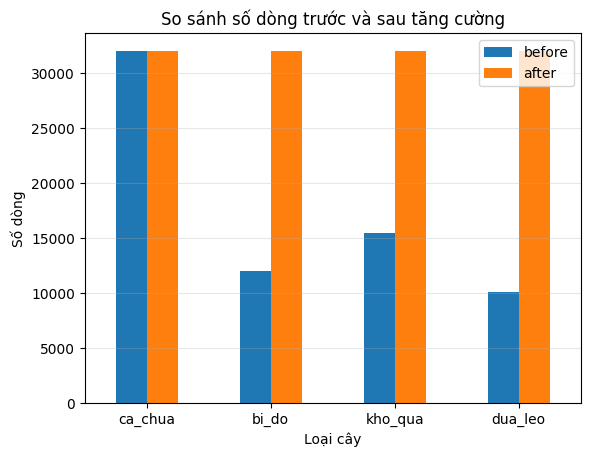

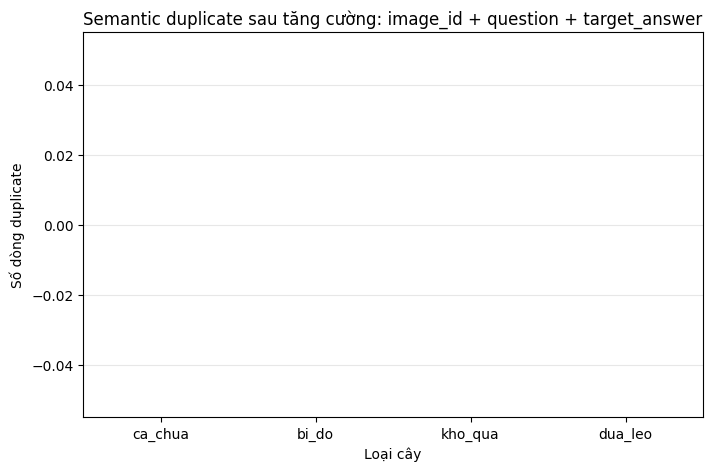

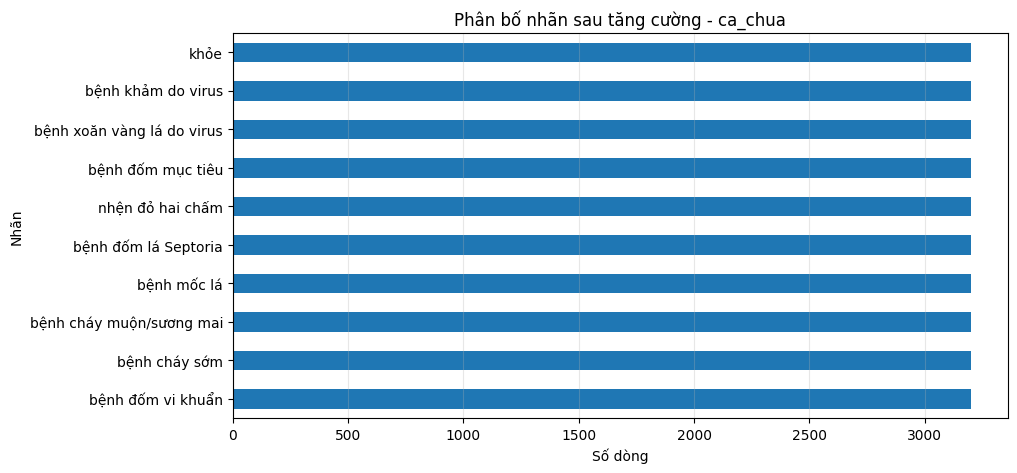

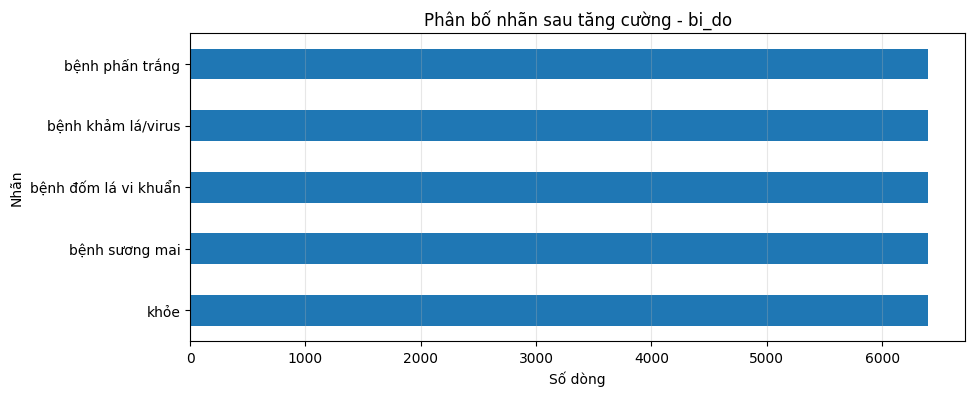

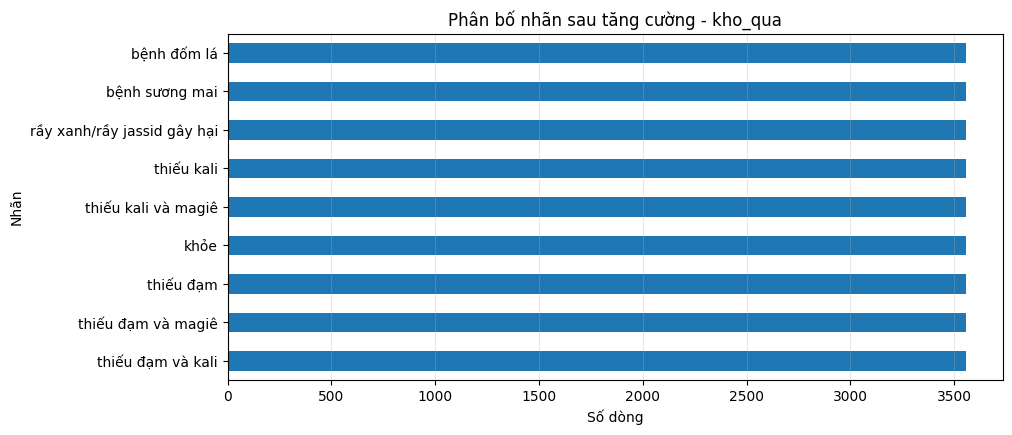

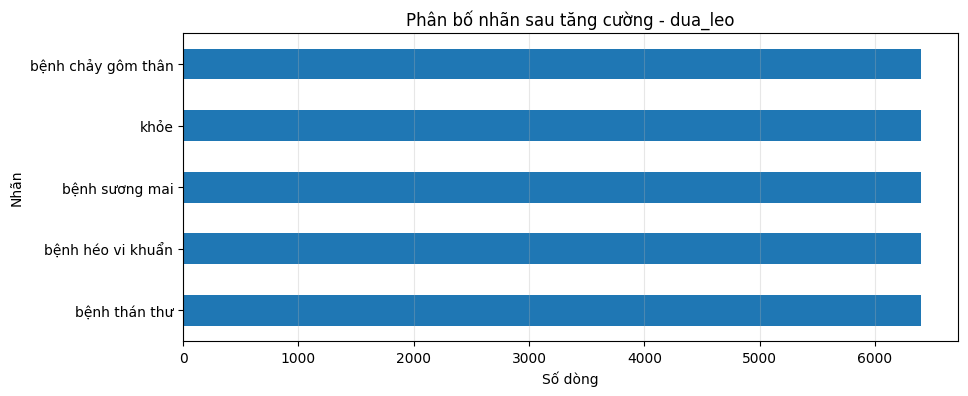

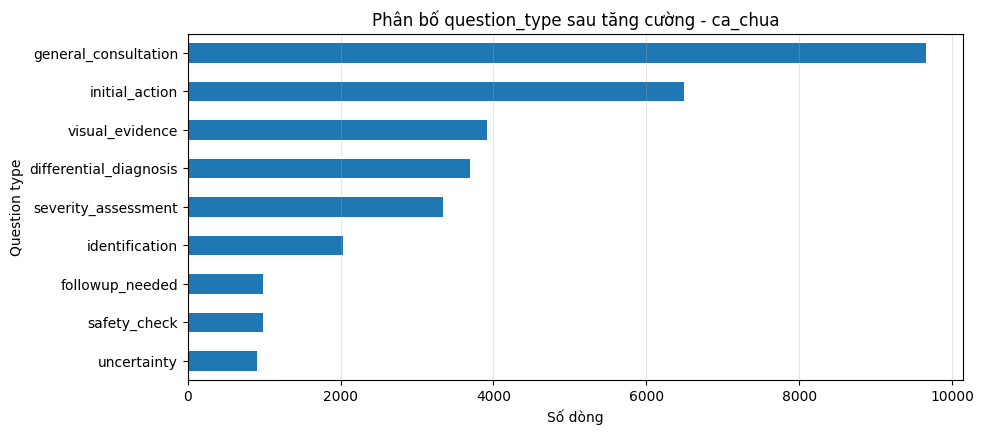

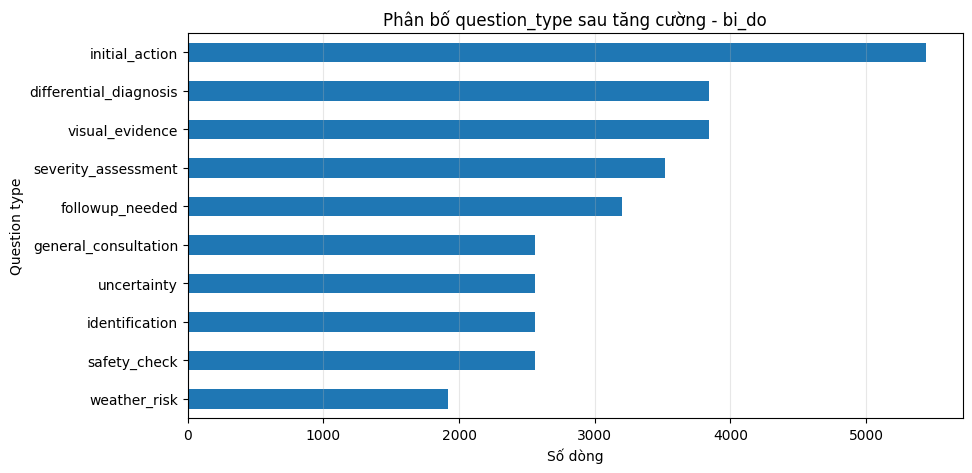

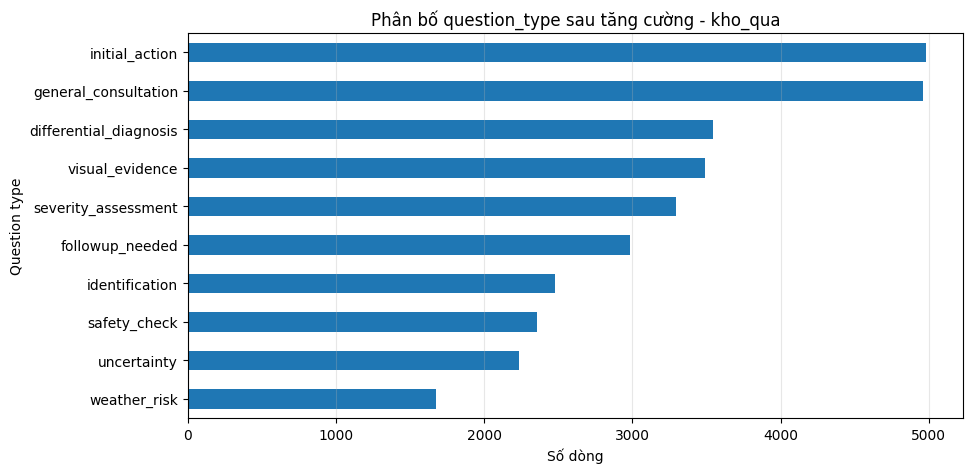

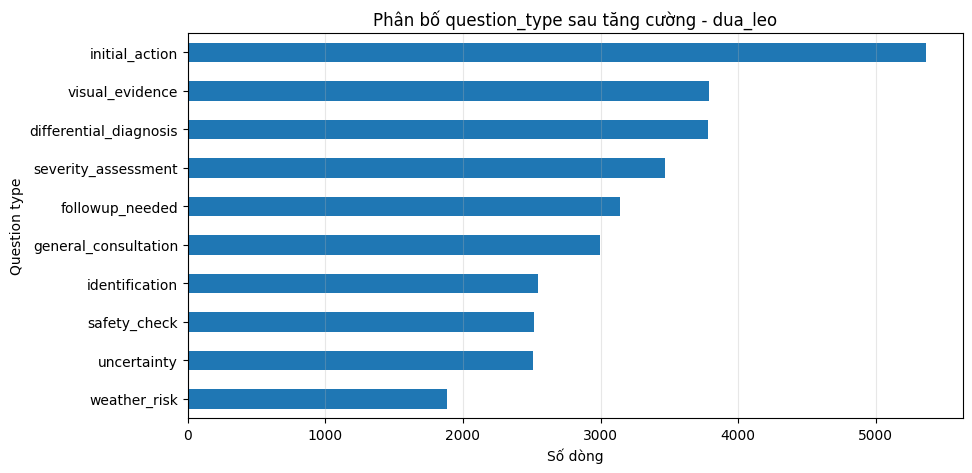

In [22]:
# CELL 10 - VISUALIZE AFTER AUGMENTATION
def plot_after_augmentation(dfs_before, augmented_dfs, content_cols):
    compare_rows = pd.DataFrame({
        "before": {k: len(v) for k, v in dfs_before.items()},
        "after": {k: len(v) for k, v in augmented_dfs.items()},
    })
    plt.figure(figsize=(8, 5))
    compare_rows.plot(kind="bar")
    plt.title("So sánh số dòng trước và sau tăng cường")
    plt.xlabel("Loại cây")
    plt.ylabel("Số dòng")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    semantic_dups = pd.Series({
        k: v.duplicated(subset=["image_id", "question", "target_answer"]).sum()
        for k, v in augmented_dfs.items()
    })
    plt.figure(figsize=(8, 5))
    semantic_dups.plot(kind="bar")
    plt.title("Semantic duplicate sau tăng cường: image_id + question + target_answer")
    plt.xlabel("Loại cây")
    plt.ylabel("Số dòng duplicate")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    for crop_key, df in augmented_dfs.items():
        counts = df["canonical_label"].value_counts().sort_values(ascending=True)
        plt.figure(figsize=(10, max(4, len(counts) * 0.5)))
        counts.plot(kind="barh")
        plt.title(f"Phân bố nhãn sau tăng cường - {crop_key}")
        plt.xlabel("Số dòng")
        plt.ylabel("Nhãn")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

    for crop_key, df in augmented_dfs.items():
        counts = df["question_type"].value_counts().sort_values(ascending=True)
        plt.figure(figsize=(10, max(4, len(counts) * 0.5)))
        counts.plot(kind="barh")
        plt.title(f"Phân bố question_type sau tăng cường - {crop_key}")
        plt.xlabel("Số dòng")
        plt.ylabel("Question type")
        plt.grid(axis="x", alpha=0.3)
        plt.show()

plot_after_augmentation(dfs, augmented_dfs, CONTENT_COLS)